# The shape and volume of air, kernels, and cracks, in a nutshell — trait prediction & PCA (minimal reproduction)

**Paper:** Amézquita et al., *The shape and volume of air, kernels, and cracks, in a nutshell*, bioRxiv v1 (2023), DOI [10.1101/2023.09.26.559651](https://doi.org/10.1101/2023.09.26.559651)

**Author code:** [amezqui3/walnut_tda](https://github.com/amezqui3/walnut_tda) @ commit `f8047379b290df451005d8733b31f8947f09c8f3` (MIT). This notebook re-executes, with light adaptations, the authors' own Python notebooks:

- `jupyter/12_data_prediction-easeofremoval.ipynb`, `...-shellstrength.ipynb`, `...-kernelpercentage.ipynb` — Spearman screening → Lasso regularization sweep → repeated 70/30 train/test → 1–6 variable stepwise best-subset selection.
- `jupyter/11_data_reduction.ipynb` (code cells) — six-trait PCA of select image-based phenotypes.

**Scope (one example experience):** from accession-averaged walnut morphological and breeding-trait tables, reproduce (1) Spearman correlation screening, (2) Lasso α sweep and coefficient selection, (3) 1–6 variable stepwise regression for **Ease of Removal**, **Shell Strength**, and **Kernel Weight Ratio**, and (4) the six-trait PCA with PC1/PC2 colored by the three breeding traits.

**Adaptations (documented):** figures are shown inline instead of written to repository paths; the stepwise search enumerates subset sizes 1–6 (the paper reports 1–6 variable models); if the coefficient-selected feature pool exceeds 14 features, only the top 14 by |mean coefficient| enter the combinatorial search (a notice is printed). A one-example run does not verify dataset-level accuracy claims of the paper.

**実行状況 / Execution status:** Verified — 完全な新規 Colab CPU ランタイム (Standard) で 2026-10-02 に Run all を最初から最後まで実行し、全セルがエラーなく完了 (所要約 180 秒)。**Verified — executed end-to-end without errors on a fresh Colab CPU (Standard) runtime on 2026-10-02; wall time ~180 s.**

**日本語の概要:** 本ノートブックは、アクセッション平均の形質表から、(1) Spearman 相関による形質スクリーニング、(2) Lasso 正則化αスイープ、(3) 100 回の 70/30 分割による 1–6 変数のステップワイズ回帰 (Ease of Removal / Shell Strength / Kernel Weight Ratio)、(4) 6 形質の PCA を再現します。著者のコード (walnut_tda) をそのまま軽い改変付きで実行します。CPU ランタイムのみを想定 (GPU 不要)。


## 1. Runtime selection & environment

This notebook is **CPU-only**: the method is tabular statistics (pandas / NumPy / SciPy / scikit-learn); no GPU code path exists in the author pipeline. Select the plain **CPU** runtime (Runtime → Change runtime type → CPU). Expected end-to-end time on a fresh Colab CPU runtime is roughly 10–20 minutes, dominated by the Lasso fits (~10⁵ small model fits).

**日本語:** 本ノートブックは CPU のみで実行できます (表形式の統計処理のため GPU は不要)。所要時間は目安 10–20 分 (Lasso の小規模フィット多数が主)。ランタイムは標準 CPU を選択してください。


In [ ]:

import sys, platform, time
import numpy as np
import pandas as pd
import scipy, sklearn

t0_notebook = time.time()
print("python:", sys.version.split()[0], "| platform:", platform.machine())
for m in (np, pd, scipy, sklearn):
    print(m.__name__, m.__version__)
import matplotlib
print("matplotlib", matplotlib.__version__)


python: 3.13.15 | platform: x86_64
numpy 2.1.3
pandas 2.2.3
scipy 1.16.3
sklearn 1.6.1
matplotlib 3.10.0


## 2. Data acquisition with provenance

Download the two phenotype CSVs from the author repository at the pinned commit `f8047379b290df451005d8733b31f8947f09c8f3` and verify their integrity by git blob SHA-1 (`sha1("blob <len>\0" + bytes)`) against the GitHub tree API, plus SHA-256. Expected: `qual_quant_accession_summary.csv` 155,152 B (blob `a2a671448dd9e1bee75b97ddddbdd10c1128f63f`), `col_labels.csv` 1,486 B (blob `c2e5a74ad26d3a0d92a7eff89eb9bc6e38cd31ba`).

**日本語:** ピン留めしたコミットから 2 つの CSV をダウンロードし、GitHub tree API の blob SHA-1 と SHA-256 で完全性を検証します。


In [ ]:

import hashlib, json, urllib.request

COMMIT = "f8047379b290df451005d8733b31f8947f09c8f3"
BASE = f"https://raw.githubusercontent.com/amezqui3/walnut_tda/{COMMIT}"

def get(url, timeout=180):
    req = urllib.request.Request(url, headers={"User-Agent": "colab-notebook"})
    with urllib.request.urlopen(req, timeout=timeout) as r:
        return r.read()

EXPECTED = {
    "hpcc/traditional/qual_quant_accession_summary.csv": (155152, "a2a671448dd9e1bee75b97ddddbdd10c1128f63f"),
    "hpcc/traditional/col_labels.csv": (1486, "c2e5a74ad26d3a0d92a7eff89eb9bc6e38cd31ba"),
}

tree = json.loads(get(f"https://api.github.com/repos/amezqui3/walnut_tda/git/trees/{COMMIT}?recursive=1"))
assert not tree.get("truncated", False), "tree API truncated"
api_info = {e["path"]: e for e in tree["tree"]}

data_dir = "/content/walnut_tda_data"
import pathlib
pathlib.Path(data_dir).mkdir(exist_ok=True)

for rel, (size, blob) in EXPECTED.items():
    b = get(f"{BASE}/{rel}")
    got_blob = hashlib.sha1(b"blob %d\0" % len(b) + b).hexdigest()
    assert len(b) == size and got_blob == blob, f"integrity failure: {rel}"
    print(f"{rel}: {len(b)} B  blob-sha1 OK  sha256={hashlib.sha256(b).hexdigest()[:16]}…")
    (pathlib.Path(data_dir) / pathlib.Path(rel).name).write_bytes(b)


hpcc/traditional/qual_quant_accession_summary.csv: 155152 B  blob-sha1 OK  sha256=f758c7f995512abf…
hpcc/traditional/col_labels.csv: 1486 B  blob-sha1 OK  sha256=10ae140688fa5cc3…


## 3. Load and preprocess (faithful to `12_data_prediction-*.ipynb`)

Load the accession summary; drop rows with `PercentKernel == -1`; rescale `TipShrivel`, `MinorShrivel`, `MajorShrivel`, `PercentKernel` to [0,1]; log-transform columns whose unit contains `m`; and define `data` by additionally dropping the `EaseOfRemoval == 7.5` accession (used by regression, kept for correlations exactly as the authors did). Build the deterministic 70/30 split index arrays (`N = 1000` splits, seeded per split).

**日本語:** アクセッション要約表を読み込み、`PercentKernel == -1` 行の削除、4 形質の [0,1] スケーリング、単位に `m` を含む列の対数変換、回帰用 `data` から `EaseOfRemoval == 7.5` の除外 (相関では保持) を行います。70/30 分割を 1000 回、分割ごとにシードを固定して作成します。


In [ ]:

INI_N, END_N = 3, 52
PERBASIS = "accession"

df = pd.read_csv(f"{data_dir}/qual_quant_{PERBASIS}_summary.csv")
df = df.drop(index=df[df["PercentKernel"] == -1].index)
df["TipShrivel"] /= 100
df["MinorShrivel"] /= 100
df["MajorShrivel"] /= 100
df["PercentKernel"] /= 100

labels = pd.read_csv(f"{data_dir}/col_labels.csv", dtype=str, keep_default_na=False)
print("labels:", labels.shape)

colnames = df.columns
for i in range(len(colnames)):
    if "m" in labels.col_units[i]:
        df[colnames[i]] = np.log(df[colnames[i]])

earliest = df[df["EaseOfRemoval"] == 7.5].index.values
data = df.drop(index=earliest)
print("df:", df.shape, "| data (regression):", data.shape)

N_SPLITS = 1000
arr = np.arange(len(data))
testN = int(np.ceil(len(arr) * 0.7))
choice = np.zeros((N_SPLITS, testN), dtype=int)
nonchoice = np.zeros((N_SPLITS, len(arr) - testN), dtype=int)
for j in range(N_SPLITS):
    rng = np.random.default_rng(j)
    choice[j] = rng.choice(arr, testN, replace=False)
    nonchoice[j] = np.setxor1d(arr, choice[j])
print("splits:", choice.shape, nonchoice.shape)


labels: (67, 2)
df: (149, 67) | data (regression): (148, 67)
splits: (1000, 104) (1000, 44)


## 4. Target distributions

Show the distribution of each of the three breeding targets, as in the authors' histograms.

**日本語:** 3 つの目的形質の分布をヒストグラムで表示します。


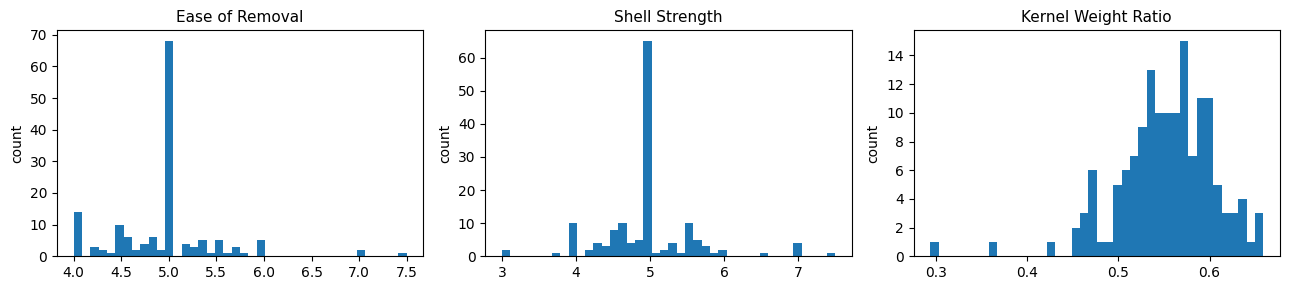

In [ ]:

import matplotlib.pyplot as plt

targets = ["EaseOfRemoval", "ShellStrength", "PercentKernel"]
target_titles = {"EaseOfRemoval": "Ease of Removal", "ShellStrength": "Shell Strength", "PercentKernel": "Kernel Weight Ratio"}

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, yv in zip(axes, targets):
    ax.hist(df[yv].values, bins=40)
    ax.set_title(target_titles[yv], fontsize=11)
    ax.set_ylabel("count")
fig.tight_layout()
plt.show()


## 5. Spearman correlation screening

For each target, compute Spearman rank correlation of every morphological column (3..52) against the target on `df`, keep columns with p < 0.05 (`s_mask`), and rank them by |ρ|. This is the authors' feature-screening step.

**日本語:** 形質列 (3..52) と目的形質の Spearman 相関を計算し、p < 0.05 の列だけを次段の特徴として採用します。


In [ ]:

from scipy import stats

spearman = {}
for yv in targets:
    y1 = df[yv].values.copy()
    scorr = np.ones(END_N - INI_N)
    spval = np.zeros_like(scorr)
    for i in range(len(scorr)):
        x = df.iloc[:, INI_N + i].values
        scorr[i], spval[i] = stats.spearmanr(x, y1)
    s_mask = np.nonzero(spval < 0.05)[0]
    order = np.argsort(np.abs(scorr[s_mask]))[::-1]
    spearman[yv] = {"s_mask": s_mask}
    print(f"--- {target_titles[yv]}: {len(s_mask)} significant features (p<0.05), top 8:")
    for r, i in enumerate(order[:8]):
        print(f"  {r+1}. rho={scorr[s_mask[i]]:+.3f}  -log10(p)={-np.log10(spval[s_mask[i]]):.1f}  {labels.col_labels.iloc[INI_N + s_mask[i]]}")


--- Ease of Removal: 14 significant features (p<0.05), top 8:
  1. rho=+0.434  -log10(p)=7.5  Shell Vol Ratio
  2. rho=-0.403  -log10(p)=6.5  Air Vol Ratio
  3. rho=+0.403  -log10(p)=6.5  Shell Thickness
  4. rho=+0.351  -log10(p)=4.9  Protruding Shell Volume
  5. rho=-0.333  -log10(p)=4.5  Kernel Airless Vol Ratio
  6. rho=+0.330  -log10(p)=4.4  Packing Vol Ratio
  7. rho=-0.327  -log10(p)=4.3  Density Kernel vs Shell
  8. rho=+0.312  -log10(p)=4.0  Shell Airless Vol Ratio
--- Shell Strength: 21 significant features (p<0.05), top 8:
  1. rho=+0.729  -log10(p)=25.3  Shell Vol Ratio
  2. rho=+0.713  -log10(p)=23.7  Shell Thickness
  3. rho=-0.600  -log10(p)=15.2  Air Vol Ratio
  4. rho=+0.595  -log10(p)=14.9  Shell Airless Vol Ratio
  5. rho=-0.576  -log10(p)=13.8  Density Kernel vs Shell
  6. rho=-0.558  -log10(p)=12.8  Kernel Airless Vol Ratio
  7. rho=+0.520  -log10(p)=11.0  Shell Volume
  8. rho=+0.481  -log10(p)=9.3  Protruding Shell Volume
--- Kernel Weight Ratio: 23 significant f

## 6. Lasso α sweep (N = 1000 splits × 20 α values)

Standardize the significant features and sweep α ∈ [0.005, 0.1] with the authors' 1000 seeded 70/30 splits; report the α maximizing mean test R². The authors then fixed α = 0.025 (Ease of Removal), 0.045 (Shell Strength), 0.005 (Kernel Weight Ratio); the sweep should confirm these are near-optimal.

**日本語:** 有意形質を標準化し、著者と同じ 1000 分割で α を 20 段階スイープし、テスト R² 平均が最大の α を報告します (著者の採用値 0.025 / 0.045 / 0.005 と比較)。


In [ ]:

from sklearn import preprocessing as prep
from sklearn import linear_model as lmodel
from sklearn import metrics as mets

AUTHOR_ALPHA = {"EaseOfRemoval": 0.025, "ShellStrength": 0.045, "PercentKernel": 0.005}
alphas = np.linspace(0.005, 0.1, 20)
t0 = time.time()

sweep = {}
for yv in targets:
    s_mask = spearman[yv]["s_mask"]
    X = data.iloc[:, INI_N + s_mask].values.copy()
    y = data[yv].values.copy()
    Xscaler = prep.StandardScaler().fit(X)
    Xs = Xscaler.transform(X)
    mean_test = np.zeros(len(alphas))
    for a_i, alpha in enumerate(alphas):
        R2 = np.zeros((N_SPLITS, 2))
        for i in range(N_SPLITS):
            m = lmodel.Lasso(alpha=alpha).fit(Xs[choice[i]], y[choice[i]])
            R2[i, 0] = m.score(Xs[choice[i]], y[choice[i]])
            R2[i, 1] = mets.r2_score(y[nonchoice[i]], m.predict(Xs[nonchoice[i]]))
        mean_test[a_i] = R2[:, 1].mean()
    sweep[yv] = {"Xscaler": Xscaler, "Xs": Xs, "y": y, "mean_test": mean_test}
    print(f"{target_titles[yv]}: best α={alphas[np.argmax(mean_test)]:.3f} "
          f"(test R²={mean_test.max():.3f}) | author α={AUTHOR_ALPHA[yv]}")
print(f"[α sweep took {time.time()-t0:.0f}s]")


Ease of Removal: best α=0.025 (test R²=0.290) | author α=0.025


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.181e-02, tolerance: 4.770e-03
  model = cd_fast.enet_coordinate_descent(


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.680e-03, tolerance: 3.675e-03
  model = cd_fast.enet_coordinate_descent(


Shell Strength: best α=0.045 (test R²=0.599) | author α=0.045


Kernel Weight Ratio: best α=0.005 (test R²=0.816) | author α=0.005
[α sweep took 106s]


## 7. Final Lasso fits and coefficient selection

Fit Lasso at the authors' fixed α with 1000 splits, collect coefficients, and retain features whose |mean coefficient| exceeds the authors' thresholds (0.01 / 0.0051 / 0.001). Show the coefficient distributions of retained features.

**日本語:** 著者が固定した α で 1000 分割の Lasso を再実行し、|平均係数| が著者のしきい値を超える形質を採用します。採用形質の係数分布を表示します。


Ease of Removal: 8 retained features
   - Shell Volume
   - Air Vol Ratio
   - Shell Vol Ratio
   - Packing Vol Ratio
   - Protruding Shell Ratio
   - Protruding Shell Volume
   - Kernel Ratio Convex Area
   - Density Packing vs Kernel


Shell Strength: 7 retained features
   - Shell Volume
   - Shell Vol Ratio
   - Packing Vol Ratio
   - Shell Thickness
   - Density Kernel vs Shell
   - Kernel Feret Ratio
   - Kernel Airless Vol Ratio


Kernel Weight Ratio: 4 retained features
   - Shell Vol Ratio
   - Shell Thickness
   - Kernel Airless Vol Ratio
   - Shell Airless Vol Ratio


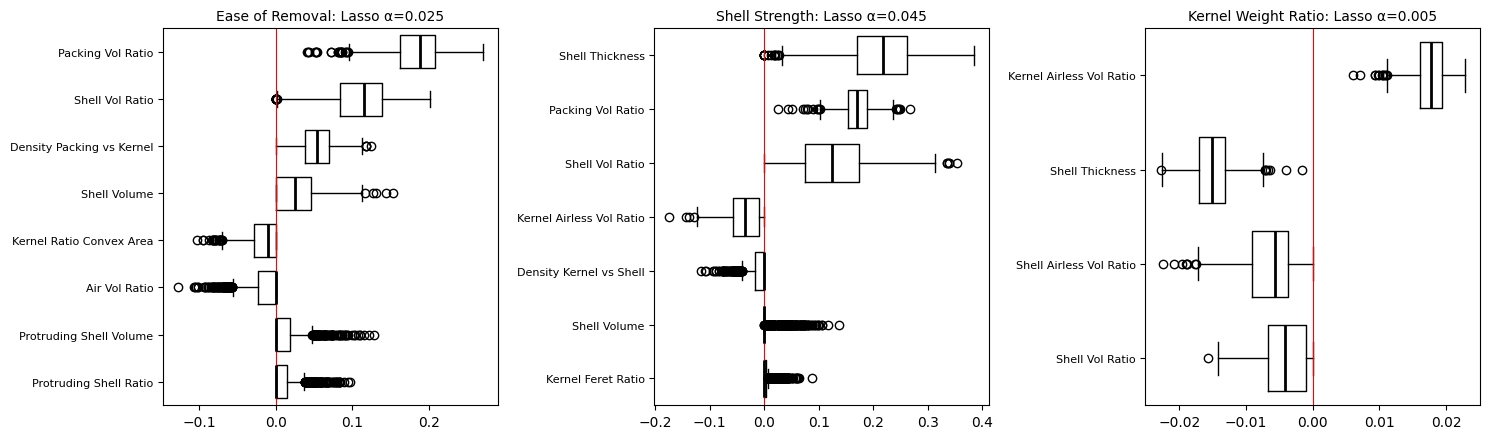

In [ ]:

COEF_THRESH = {"EaseOfRemoval": 0.01, "ShellStrength": 0.0051, "PercentKernel": 0.001}
MAX_M = 14  # adaptation: cap the combinatorial pool (see title notice)

final = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, yv in zip(axes, targets):
    Xs, y = sweep[yv]["Xs"], sweep[yv]["y"]
    coefs = np.zeros((N_SPLITS, Xs.shape[1]))
    for i in range(N_SPLITS):
        m = lmodel.Lasso(alpha=AUTHOR_ALPHA[yv]).fit(Xs[choice[i]], y[choice[i]])
        coefs[i] = m.coef_
    fabs = np.abs(coefs.mean(axis=0))
    r_mask = fabs > COEF_THRESH[yv]
    capped = False
    if r_mask.sum() > MAX_M:
        top = np.argsort(fabs[r_mask])[::-1][:MAX_M]
        keep = np.nonzero(r_mask)[0][top]
        new_mask = np.zeros_like(r_mask)
        new_mask[keep] = True
        r_mask, capped = new_mask, True
    final[yv] = {"coefs": coefs, "r_mask": r_mask}
    names = labels.col_labels.iloc[INI_N + spearman[yv]["s_mask"]].values[r_mask]
    print(f"{target_titles[yv]}: {r_mask.sum()} retained features"
          + (f" (capped from {(fabs>COEF_THRESH[yv]).sum()} to top-{MAX_M} by |mean coef|)" if capped else ""))
    for nm in names:
        print("   -", nm)
    feat_idx = np.nonzero(r_mask)[0]
    order = np.argsort(fabs[feat_idx])
    ax.boxplot([coefs[:, i] for i in feat_idx[order]], vert=False, widths=0.7,
               medianprops={"lw": 2, "color": "k"})
    ax.axvline(0, c="r", lw=0.8)
    ax.set_yticklabels(labels.col_labels.iloc[INI_N + spearman[yv]["s_mask"]].values[feat_idx[order]], fontsize=8)
    ax.set_title(f"{target_titles[yv]}: Lasso α={AUTHOR_ALPHA[yv]}", fontsize=10)
fig.tight_layout()
plt.show()


## 8. 1–6 variable stepwise best-subset selection (N = 100 splits)

For each target and each subset size 1–6, fit every feature combination over the retained pool across 100 fresh splits (single-feature models use OLS `LinearRegression`, larger ones use Lasso at the fixed α, exactly as the authors), and record train/test R². Report the best combination per size by mean test R². This is the most compute-heavy stage.

**日本語:** 採用形質プールから、サイズ 1–6 のすべての組み合わせについて 100 分割でフィットし (1 変数は OLS、2 変数以上は Lasso)、各サイズでテスト R² 平均が最良の組み合わせを報告します。計算量が最大のステップです。


In [ ]:

import itertools as it

N_STEP = 100
schoice = choice[:N_STEP]
snonchoice = nonchoice[:N_STEP]

def best_subsets(yv):
    s_mask = spearman[yv]["s_mask"]
    X_all = sweep[yv]["Xscaler"].transform(data.iloc[:, INI_N + s_mask].values.copy())
    X = X_all[:, final[yv]["r_mask"]]
    y = data[yv].values.copy()
    names = labels.col_labels.iloc[INI_N + s_mask].values[final[yv]["r_mask"]]
    M = X.shape[1]
    results = {}
    t0 = time.time()
    for k in range(1, 7):
        combos = list(it.combinations(range(M), min(k, M)))
        best = None
        for comb in combos:
            X1 = X[:, comb].reshape(-1, 1) if k == 1 else X[:, comb]
            R2 = np.zeros((N_STEP, 2))
            for j in range(N_STEP):
                if k == 1:
                    m = lmodel.LinearRegression().fit(X1[schoice[j]], y[schoice[j]])
                else:
                    m = lmodel.Lasso(alpha=AUTHOR_ALPHA[yv]).fit(X1[schoice[j]], y[schoice[j]])
                R2[j, 0] = m.score(X1[schoice[j]], y[schoice[j]])
                R2[j, 1] = mets.r2_score(y[snonchoice[j]], m.predict(X1[snonchoice[j]]))
            mt = R2[:, 1].mean()
            if best is None or mt > best[1]:
                best = (comb, mt, R2)
        results[k] = {"comb": best[0], "mean_test_R2": best[1], "R2": best[2], "names": [names[i] for i in best[0]]}
        print(f"{target_titles[yv]} | size {k}: test R²={best[1]:.3f} <- {results[k]['names']}")
    print(f"[{target_titles[yv]} stepwise took {time.time()-t0:.0f}s, pool M={M}]\n")
    return results

stepwise = {yv: best_subsets(yv) for yv in targets}


Ease of Removal | size 1: test R²=0.183 <- ['Air Vol Ratio']


Ease of Removal | size 2: test R²=0.294 <- ['Shell Vol Ratio', 'Packing Vol Ratio']


Ease of Removal | size 3: test R²=0.303 <- ['Shell Vol Ratio', 'Packing Vol Ratio', 'Density Packing vs Kernel']


Ease of Removal | size 4: test R²=0.303 <- ['Shell Volume', 'Shell Vol Ratio', 'Packing Vol Ratio', 'Density Packing vs Kernel']


Ease of Removal | size 5: test R²=0.296 <- ['Shell Vol Ratio', 'Packing Vol Ratio', 'Protruding Shell Ratio', 'Protruding Shell Volume', 'Density Packing vs Kernel']


...

Shell Strength | size 6: test R²=0.606 <- ['Shell Volume', 'Packing Vol Ratio', 'Shell Thickness', 'Density Kernel vs Shell', 'Kernel Feret Ratio', 'Kernel Airless Vol Ratio']
[Shell Strength stepwise took 21s, pool M=7]



Kernel Weight Ratio | size 1: test R²=0.731 <- ['Shell Airless Vol Ratio']


Kernel Weight Ratio | size 2: test R²=0.816 <- ['Shell Thickness', 'Kernel Airless Vol Ratio']


Kernel Weight Ratio | size 3: test R²=0.817 <- ['Shell Thickness', 'Kernel Airless Vol Ratio', 'Shell Airless Vol Ratio']
Kernel Weight Ratio | size 4: test R²=0.814 <- ['Shell Vol Ratio', 'Shell Thickness', 'Kernel Airless Vol Ratio', 'Shell Airless Vol Ratio']


Kernel Weight Ratio | size 5: test R²=0.814 <- ['Shell Vol Ratio', 'Shell Thickness', 'Kernel Airless Vol Ratio', 'Shell Airless Vol Ratio']
Kernel Weight Ratio | size 6: test R²=0.814 <- ['Shell Vol Ratio', 'Shell Thickness', 'Kernel Airless Vol Ratio', 'Shell Airless Vol Ratio']
[Kernel Weight Ratio stepwise took 3s, pool M=4]



## 9. Stepwise results: R² by model size and feature usage

Boxplots of train/test R² for the best subset of each size (1–6), with the feature-usage matrix of the best subsets.

**日本語:** 各サイズの最良サブセットにおける train/test R² の箱ひげ図と、最良サブセットで使用された形質の使用行列を表示します。


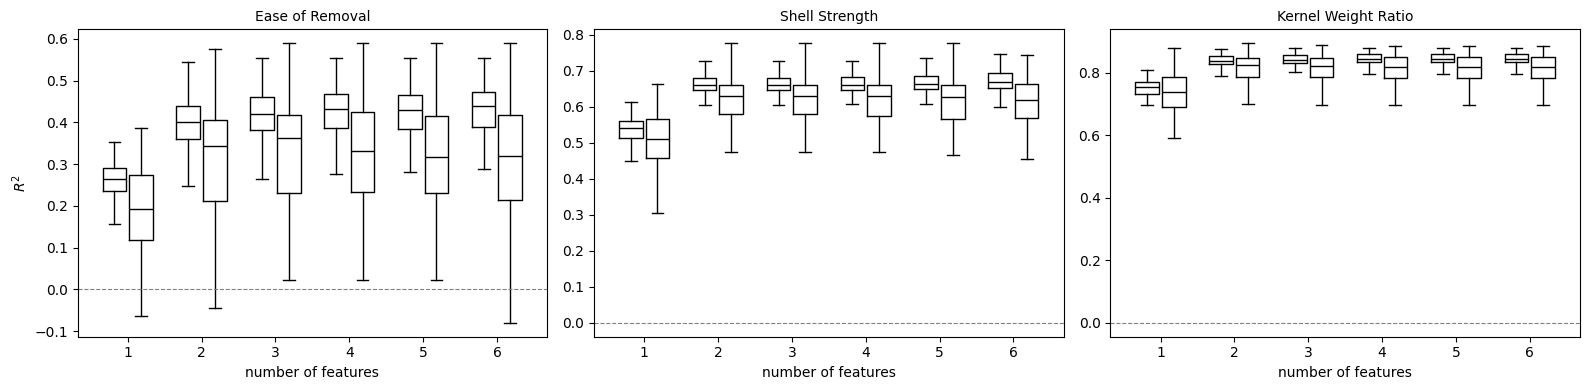

Best subset by size (mean test R²):
--- Ease of Removal
  size 1: R²=0.183  ['Air Vol Ratio']
  size 2: R²=0.294  ['Shell Vol Ratio', 'Packing Vol Ratio']
  size 3: R²=0.303  ['Shell Vol Ratio', 'Packing Vol Ratio', 'Density Packing vs Kernel']
  size 4: R²=0.303  ['Shell Volume', 'Shell Vol Ratio', 'Packing Vol Ratio', 'Density Packing vs Kernel']
  size 5: R²=0.296  ['Shell Vol Ratio', 'Packing Vol Ratio', 'Protruding Shell Ratio', 'Protruding Shell Volume', 'Density Packing vs Kernel']
  size 6: R²=0.293  ['Shell Volume', 'Shell Vol Ratio', 'Packing Vol Ratio', 'Protruding Shell Ratio', 'Protruding Shell Volume', 'Density Packing vs Kernel']
--- Shell Strength
  size 1: R²=0.492  ['Shell Vol Ratio']
  size 2: R²=0.616  ['Packing Vol Ratio', 'Shell Thickness']
  size 3: R²=0.616  ['Shell Volume', 'Packing Vol Ratio', 'Shell Thickness']
  size 4: R²=0.614  ['Shell Volume', 'Packing Vol Ratio', 'Shell Thickness', 'Density Kernel vs Shell']
  size 5: R²=0.610  ['Shell Volume', 'Packing 

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, yv in zip(axes, targets):
    res = stepwise[yv]
    sizes = sorted(res)
    tr = [res[k]["R2"][:, 0] for k in sizes]
    te = [res[k]["R2"][:, 1] for k in sizes]
    pos = np.arange(len(sizes))
    ax.boxplot(tr, positions=pos - 0.18, widths=0.32, sym="", medianprops={"color": "k"})
    ax.boxplot(te, positions=pos + 0.18, widths=0.32, sym="", medianprops={"color": "k"})
    ax.axhline(0, c="gray", ls="--", lw=0.8)
    ax.set_xticks(pos, [str(k) for k in sizes])
    ax.set_xlabel("number of features")
    ax.set_title(target_titles[yv], fontsize=10)
axes[0].set_ylabel("$R^2$")
fig.tight_layout()
plt.show()

print("Best subset by size (mean test R²):")
for yv in targets:
    print(f"--- {target_titles[yv]}")
    for k in sorted(stepwise[yv]):
        r = stepwise[yv][k]
        print(f"  size {k}: R²={r['mean_test_R2']:.3f}  {r['names']}")


## 10. Six-trait PCA (faithful to `11_data_reduction.ipynb`)

The authors' data-reduction notebook selects six image-based phenotypes at df column positions `[21, 23, 24, 51, 49, 26]`, standardizes them, and runs a full-SVD 2-component PCA over **all** accessions (the `EaseOfRemoval == 7.5` accession is marked but not dropped). PC1/PC2 are colored by the three breeding traits. Column identities are read from `col_labels.csv` at runtime (not hardcoded here).

**日本語:** 著者の次元削減ノートブック通り、df の 6 列 `[21,23,24,51,49,26]` を標準化し、全アクセッション (7.5 行はマークのみ) でフル SVD の 2 成分 PCA を実行します。PC1/PC2 を 3 つの育種形質で着色して表示します。


Six traits (from col_labels.csv):
  col 21: Air Vol Ratio [ [%]]
  col 23: Shell Vol Ratio [ [%]]
  col 24: Packing Vol Ratio [ [%]]
  col 51: Shell Airless Vol Ratio [ [%]]
  col 49: Kernel Airless Vol Ratio [ [%]]
  col 26: Shell Thickness [ [mm]]
imgfeats: (149, 6)
explained variance %: [63.363 22.029]
cumulative %: [63.363 85.392]


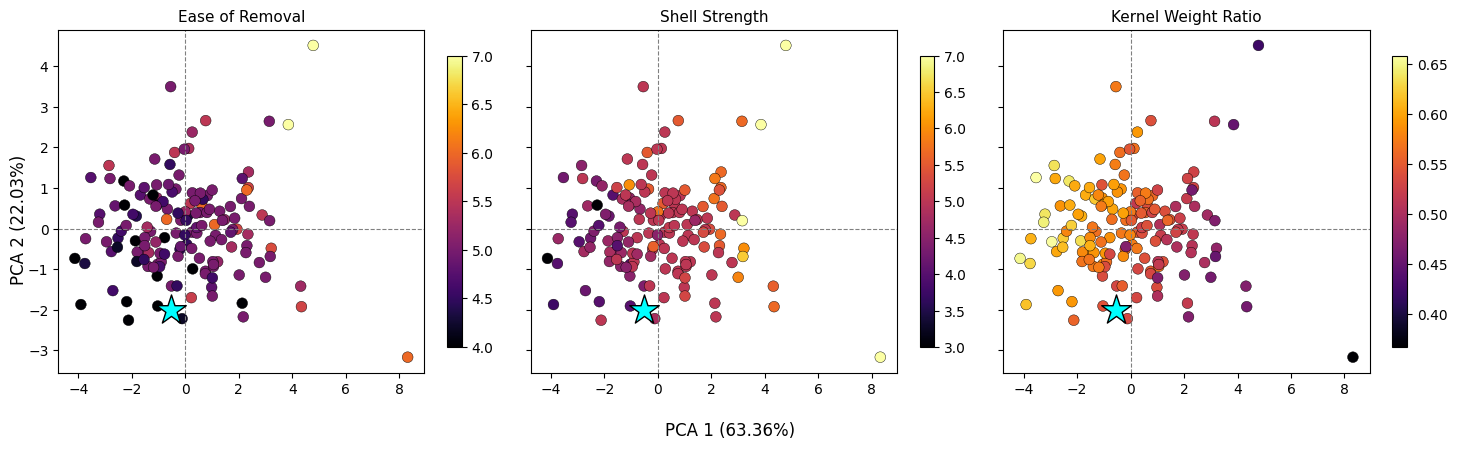

In [ ]:

INTEREST = np.asarray([21, 23, 24, 51, 49, 26])  # df column positions (author: interest + iniN)
df_pca = pd.read_csv(f"{data_dir}/qual_quant_{PERBASIS}_summary.csv", dtype={1: str})
df_pca = df_pca.drop(index=df_pca[df_pca["PercentKernel"] == -1].index)
df_pca["TipShrivel"] /= 100
df_pca["MinorShrivel"] /= 100
df_pca["MajorShrivel"] /= 100
df_pca["PercentKernel"] /= 100

print("Six traits (from col_labels.csv):")
for c in INTEREST:
    print(f"  col {c}: {labels.col_labels.iloc[c]} [{labels.col_units.iloc[c]}]")

imgfeats = df_pca.iloc[:, INTEREST].values.copy()
scaler = prep.StandardScaler().fit(imgfeats)
imgfeats = scaler.transform(imgfeats)
print("imgfeats:", imgfeats.shape)

from sklearn.decomposition import PCA
pca = PCA(n_components=2, svd_solver="full")
pca.fit(imgfeats)
print("explained variance %:", (100 * pca.explained_variance_ratio_[:2]).round(3))
print("cumulative %:", (100 * np.cumsum(pca.explained_variance_ratio_)[:2]).round(3))
redux = pca.transform(imgfeats)

earliest = df_pca[df_pca["EaseOfRemoval"] == 7.5]
eidx = earliest.index.values[0]
foo = np.array(list(range(eidx)) + list(range(eidx + 1, len(df_pca))))

cattraitnames = df_pca.columns[END_N:].values[[12, 4, 13]]
traitnames = ["Ease of Removal", "Shell Strength", "Kernel Weight Ratio"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for idx in range(3):
    ax = axes[idx]
    sc = ax.scatter(redux[foo, 0], redux[foo, 1], c=df_pca.loc[foo, cattraitnames[idx]].values,
                    s=60, cmap="inferno", edgecolors="k", linewidths=0.3)
    ax.scatter(redux[eidx, 0], redux[eidx, 1], s=500, color="cyan", marker="*", edgecolors="k", zorder=3)
    ax.set_title(traitnames[idx], fontsize=11)
    ax.axvline(0, c="gray", ls="--", lw=0.8)
    ax.axhline(0, c="gray", ls="--", lw=0.8)
    plt.colorbar(sc, ax=ax, shrink=0.85)
fig.supxlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
fig.supylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
fig.tight_layout()
plt.show()


## 11. Export and interpretation

Save the best-subset table to CSV and print a compact summary. Results are from one CPU run of the authors' own pipeline on the accession-averaged table; they characterize this dataset, not the paper's CT-image findings.

**日本語:** 最良サブセット表を CSV に保存し、結果を要約します。結果はこのデータセット上の 1 回の実行によるものであり、論文の CT 画像解析の結論を検証するものではありません。


In [ ]:

rows = []
for yv in targets:
    for k in sorted(stepwise[yv]):
        r = stepwise[yv][k]
        rows.append({"target": target_titles[yv], "n_features": k,
                     "mean_test_R2": r["mean_test_R2"], "features": "; ".join(r["names"])})
out = pd.DataFrame(rows)
out.to_csv("/content/walnut_best_subsets.csv", index=False)
print(out.to_string(index=False, max_colwidth=60))
print(f"\n[notebook wall time: {time.time()-t0_notebook:.0f}s]")


             target  n_features  mean_test_R2                                                     features
    Ease of Removal           1      0.182554                                                Air Vol Ratio
    Ease of Removal           2      0.294367                           Shell Vol Ratio; Packing Vol Ratio
    Ease of Removal           3      0.302987 Shell Vol Ratio; Packing Vol Ratio; Density Packing vs Ke...
    Ease of Removal           4      0.302540 Shell Volume; Shell Vol Ratio; Packing Vol Ratio; Density...
    Ease of Removal           5      0.296246 Shell Vol Ratio; Packing Vol Ratio; Protruding Shell Rati...
    Ease of Removal           6      0.293231 Shell Volume; Shell Vol Ratio; Packing Vol Ratio; Protrud...
     Shell Strength           1      0.492416                                              Shell Vol Ratio
     Shell Strength           2      0.616370                           Packing Vol Ratio; Shell Thickness
     Shell Strength           3      

## 12. References & limitations

- Amézquita, E.J. et al. (2023). *The shape and volume of air, kernels, and cracks, in a nutshell.* bioRxiv 2023.09.26.559651. https://doi.org/10.1101/2023.09.26.559651
- Author code: https://github.com/amezqui3/walnut_tda @ `f8047379b290df451005d8733b31f8947f09c8f3` (MIT) — notebooks `12_data_prediction-*.ipynb`, `11_data_reduction.ipynb`.
- Data: `hpcc/traditional/qual_quant_accession_summary.csv`, `col_labels.csv` at the same commit (integrity-checked by git blob SHA-1).
- CT volume data (Dryad doi:10.5061/dryad.ngf1vhj09, 83 GB) and the ECT/topology phases are out of scope for this notebook.

**Limitations:** subset sizes capped at 1–6 (paper reports 1–6 variable models); combinatorial pool capped at 14 features when the coefficient threshold retains more; α-sweep and splits follow the authors' seeds (deterministic). Single-run results do not validate dataset-level claims.

**日本語:** 組み合わせ探索はサイズ 1–6、特徴プールは最大 14 に制限しています (適用時は出力に通知)。CT 体積データと ECT/トポロジー解析は対象外です。
